In [ ]:
import os
import logging
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import jax
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.orchestration.parameters import Parameters, DMRGParameters
from skqd_z2lgt.orchestration.open_output import open_output
from skqd_z2lgt.orchestration.standalone import dmrg, sample_quantum, preprocess, train_generator
from skqd_z2lgt.orchestration.io import load_crbm_train_records
from skqd_z2lgt.orchestration.diagonalize import diagonalize_in_mode

logging.basicConfig(level=logging.INFO, format='%(asctime)s:%(name)s:%(levelname)s %(message)s')
logger = logging.getLogger()
os.environ['CUDA_VISIBLE_DEVICES'] = '4,5,6,7'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
jax.config.update('jax_enable_x64', True)

In [2]:
pkgpath = Path('/data/iiyama/2dz2/experiment_sep2_kawasaki_4x8_monopole')
os.makedirs(pkgpath, exist_ok=True)

lattice = TriangularZ2Lattice('''
*-*-*-*-*╷
 * * * * *
* * * * *╎
 * * * * *
* * * * *╵
''')
lattice.activate_plaquette(13, False)

In [3]:
if os.path.exists(pkgpath / 'parameters.json'):
    parameters = open_output(pkgpath, logger=logger)
else:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service = QiskitRuntimeService(instance='ICEPP-dedicated')
    backend = service.backend('ibm_kawasaki')
    layout = lattice.layout_heavy_hex(backend.coupling_map)

    with open(pkgpath / 'lattice.json', 'w') as out:
        out.write(lattice.to_json())

    parameters = Parameters(pkgpath=str(pkgpath))
    parameters.dmrg = DMRGParameters()
    parameters.lgt.lattice = str(pkgpath / 'lattice.json')
    parameters.lgt.plaquette_energy = 1.5
    parameters.lgt.charged_plaquettes = [13]
    parameters.circuit.layout = layout
    parameters.circuit.sampled_steps = [2, 3, 4, 5, 6, 7]
    parameters.runtime.instance = 'ICEPP-dedicated'
    parameters.runtime.backend = 'ibm_kawasaki'

    open_output(parameters, logger=logger)

2026-09-03 00:09:29,588:root:INFO Validating configurations in existing file /data/iiyama/2dz2/experiment_sep2_kawasaki_4x8_monopole


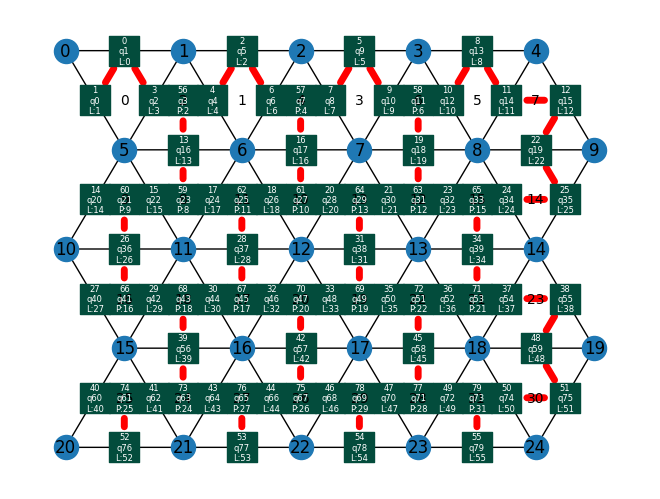

In [4]:
fig = lattice.draw_graph()
lattice.draw_qubit_graph(layout=parameters.circuit.layout, ax=fig.axes[0]);

In [5]:
dmrg(parameters, logger=logger)

2026-09-03 00:09:30,450:root:INFO DMRG result already exists in the output file.


np.float64(-63.831062577751084)

In [6]:
sample_quantum(parameters, logger=logger)

management.get:INFO:2026-09-03 00:09:35,018: Loading default saved account
2026-09-03 00:09:37,647:root:INFO Raw bitstrings already saved to file


In [7]:
preprocess(parameters, logger=logger)

2026-09-03 00:09:39,101:root:INFO Reco data for etype=exp idt=0 step=2 already exists.
2026-09-03 00:09:39,102:root:INFO Reco data for etype=exp idt=0 step=3 already exists.
2026-09-03 00:09:39,102:root:INFO Reco data for etype=exp idt=0 step=4 already exists.
2026-09-03 00:09:39,102:root:INFO Reco data for etype=exp idt=0 step=5 already exists.
2026-09-03 00:09:39,103:root:INFO Reco data for etype=exp idt=0 step=6 already exists.
2026-09-03 00:09:39,103:root:INFO Reco data for etype=exp idt=0 step=7 already exists.
2026-09-03 00:09:39,103:root:INFO Reco data for etype=ref idt=0 step=2 already exists.
2026-09-03 00:09:39,104:root:INFO Reco data for etype=ref idt=0 step=3 already exists.
2026-09-03 00:09:39,104:root:INFO Reco data for etype=ref idt=0 step=4 already exists.
2026-09-03 00:09:39,104:root:INFO Reco data for etype=ref idt=0 step=5 already exists.
2026-09-03 00:09:39,105:root:INFO Reco data for etype=ref idt=0 step=6 already exists.
2026-09-03 00:09:39,105:root:INFO Reco data

In [8]:
train_generator(parameters, logger=logger)

2026-09-03 00:09:41,633:root:INFO CRBM model for dt=0.250000 step=2 already exists.
2026-09-03 00:09:41,634:root:INFO CRBM model for dt=0.250000 step=3 already exists.
2026-09-03 00:09:41,634:root:INFO CRBM model for dt=0.250000 step=4 already exists.
2026-09-03 00:09:41,635:root:INFO CRBM model for dt=0.250000 step=5 already exists.
2026-09-03 00:09:41,635:root:INFO CRBM model for dt=0.250000 step=6 already exists.
2026-09-03 00:09:41,635:root:INFO CRBM model for dt=0.250000 step=7 already exists.
2026-09-03 00:09:41,636:root:INFO All models already trained


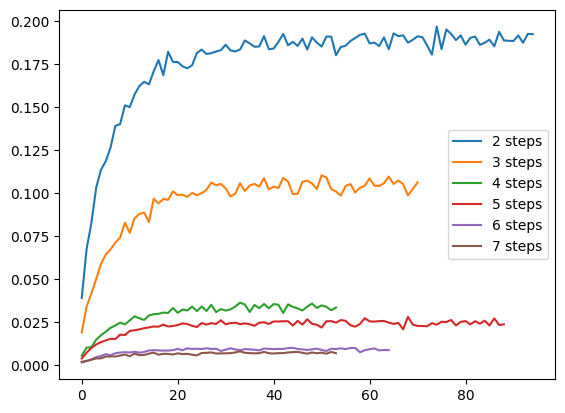

In [23]:
for istep in parameters.circuit.sampled_steps:
    records = load_crbm_train_records(parameters, 0, istep)
    plt.plot(records['test_success_rate'], label=f'{istep} steps')
plt.legend();

In [24]:
diagonalize_in_mode(parameters, 'rn', logger=logger)

2026-09-03 00:21:18,960:root:INFO Padding and stacking data
2026-09-03 00:21:19,947:jax._src.xla_bridge:INFO Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-09-03 00:21:21,177:root:INFO Using the mean of reference circuit data as single-plaquette probability
2026-09-03 00:21:21,645:root:INFO Setting up the Hamiltonian
2026-09-03 00:21:21,674:root:INFO Generating the PT core (<=6 excitations)
2026-09-03 00:21:21,698:root:INFO Starting SKQD iterations


Iteration 0: energy -63.246989203795515
Iteration 1: energy -63.278026267377314
Iteration 2: energy -63.30561270375169
Iteration 3: energy -63.32807083873011
Iteration 4: energy -63.345450993198384
Iteration 5: energy -63.35961701746874
Iteration 6: energy -63.37140974014967
Iteration 7: energy -63.38113114109535
Iteration 8: energy -63.38937732251077
Iteration 9: energy -63.39629801026051
Iteration 10: energy -63.40206897392268


-63.40206897392268

In [25]:
diagonalize_in_mode(parameters, 'cr', logger=logger)

2026-09-03 00:22:47,341:root:INFO Padding and stacking data
2026-09-03 00:22:47,383:root:INFO Loading and stacking CRBM models
2026-09-03 00:22:49,941:root:INFO Setting up the Hamiltonian
2026-09-03 00:22:49,956:root:INFO Generating the PT core (<=6 excitations)
2026-09-03 00:22:49,981:root:INFO Starting SKQD iterations


Iteration 0: energy -63.255285004391965
Iteration 1: energy -63.28964113058116
Iteration 2: energy -63.31712354587782
Iteration 3: energy -63.33900337436452
Iteration 4: energy -63.355856076528326
Iteration 5: energy -63.36941678323553
Iteration 6: energy -63.38034004216965
Iteration 7: energy -63.38925227895412
Iteration 8: energy -63.39668721743563
Iteration 9: energy -63.40302624611862
Iteration 10: energy -63.40826560285581


-63.40826560285581